In [1]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

# -----------------------------
# BASIC LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np

# -----------------------------
# VISUALIZATION LIBRARIES
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# WARNING SETTINGS
# -----------------------------
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# PREPROCESSING
# -----------------------------
from sklearn.preprocessing import (LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler)

from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score)

# -----------------------------
# METRICS
# -----------------------------
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay, RocCurveDisplay)

# -----------------------------
# LINEAR MODELS
# -----------------------------
from sklearn.linear_model import (LogisticRegression, RidgeClassifier)

# -----------------------------
# TREE-BASED MODELS
# -----------------------------
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# ENSEMBLE MODELS
# -----------------------------
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, VotingClassifier, StackingClassifier)

# -----------------------------
# SVM
# -----------------------------
from sklearn.svm import SVC

# -----------------------------
# KNN
# -----------------------------
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# BOOSTING LIBRARIES
# -----------------------------
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# -----------------------------
# DISPLAY SETTINGS
# -----------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# -----------------------------
# RANDOM STATE
# -----------------------------
RANDOM_STATE = 10

# =========================================================
# IMPORT JOBLIB
# =========================================================

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# =========================================================
# DROP UNNECESSARY COLUMNS
# =========================================================

df.drop(columns=[' fnlwgt', ' education-num'], inplace=True)

print("Unnecessary columns dropped successfully.")

Unnecessary columns dropped successfully.


In [4]:
# =========================================================
# DISPLAY FIRST 5 ROWS
# =========================================================

df.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# =========================================================
# DATASET SHAPE
# =========================================================

print("Dataset Shape :", df.shape)

Dataset Shape : (32561, 13)


In [6]:
# =========================================================
# CLEAN COLUMN NAMES
# =========================================================

df.columns = (df.columns.str.strip().str.lower().str.replace('-', '_').str.replace(' ', '_'))

print("Column names cleaned successfully.")

Column names cleaned successfully.


In [7]:
# =========================================================
# DISPLAY COLUMN NAMES
# =========================================================

df.columns

Index(['age', 'workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
       'hours_per_week', 'native_country', 'income'],
      dtype='str')

In [8]:
# =========================================================
# CHECK DATA TYPES
# =========================================================

df.dtypes

age               int64
workclass           str
education           str
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object

In [9]:
# =========================================================
# CHECK MISSING VALUES
# =========================================================

df.isnull().sum()

age               0
workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [10]:
# =========================================================
# CHECK '?' VALUES IN EACH COLUMN
# =========================================================

for column in df.columns:
    question_mark_count = (df[column] == ' ?').sum()
    
    if question_mark_count > 0:
        print(f"{column} : {question_mark_count}")

workclass : 1836
occupation : 1843
native_country : 583


In [11]:
# =========================================================
# CHECK DUPLICATE ROWS
# =========================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 3465


In [12]:
# =========================================================
# REMOVE DUPLICATE ROWS
# =========================================================

df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

print("Duplicate rows removed successfully.")

Duplicate rows removed successfully.


In [13]:
# =========================================================
# CHECK DATASET SHAPE AFTER REMOVING DUPLICATES
# =========================================================

print("Updated Dataset Shape :", df.shape)

Updated Dataset Shape : (29096, 13)


In [14]:
# =========================================================
# TARGET VARIABLE DISTRIBUTION
# =========================================================

df['income'].value_counts()

income
<=50K    21886
>50K      7210
Name: count, dtype: int64

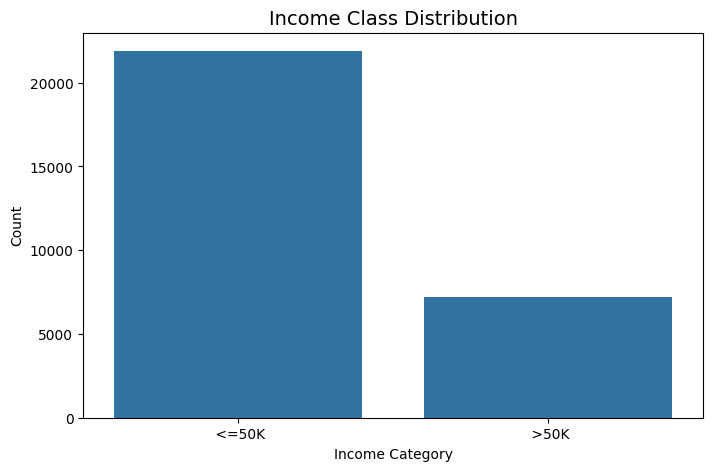

In [15]:
# =========================================================
# VISUALIZE TARGET VARIABLE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(x='income', data=df)

plt.title("Income Class Distribution", fontsize=14)
plt.xlabel("Income Category")
plt.ylabel("Count")

plt.show()

In [16]:
# =========================================================
# REPLACE '?' WITH NaN
# =========================================================

df.replace(' ?', np.nan, inplace=True)

print("Question marks replaced with NaN successfully.")

Question marks replaced with NaN successfully.


In [17]:
# =========================================================
# CHECK MISSING VALUES AGAIN
# =========================================================

df.isnull().sum()

age                  0
workclass         1632
education            0
marital_status       0
occupation        1639
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     580
income               0
dtype: int64

In [18]:
# =========================================================
# FILL MISSING VALUES USING MODE
# =========================================================

df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])

df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

df['native_country'] = df['native_country'].fillna(df['native_country'].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [19]:
# =========================================================
# VERIFY MISSING VALUES AFTER IMPUTATION
# =========================================================

df.isnull().sum()

age               0
workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

# Model 1 - Before EDA

In [20]:
# =========================================================
# LABEL ENCODING
# =========================================================

# Create a copy of dataset
df_encoded = df.copy()

# Initialize Label Encoder
le = LabelEncoder()

# Encode categorical columns
for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


In [21]:
# =========================================================
# CHECK TARGET VARIABLE ENCODING
# =========================================================

df_encoded['income'].value_counts()

income
0    21886
1     7210
Name: count, dtype: int64

In [22]:
# =========================================================
# CREATE BASELINE DATAFRAME
# =========================================================

df_baseline = df_encoded.copy()

print("Baseline dataframe created successfully.")

Baseline dataframe created successfully.


In [23]:
# =========================================================
# SEPARATE FEATURES & TARGET
# =========================================================

x = df_baseline.drop('income', axis=1)

y = df_baseline['income']

print("Features Shape :", x.shape)
print("Target Shape   :", y.shape)

Features Shape : (29096, 12)
Target Shape   : (29096,)


In [24]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=10, stratify=y)

print("x_train Shape :", x_train.shape)
print("x_test Shape  :", x_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

x_train Shape : (23276, 12)
x_test Shape  : (5820, 12)
y_train Shape : (23276,)
y_test Shape  : (5820,)


In [25]:
# =========================================================
# CREATE BASELINE MODELS
# =========================================================

models = {

    # =====================================================
    # LINEAR MODELS
    # =====================================================

    "Logistic Regression Baseline": LogisticRegression(random_state=10),

    "Ridge Classifier Baseline": RidgeClassifier(random_state=10),

    "Lasso Logistic Regression Baseline": LogisticRegression(penalty='l1', solver='liblinear', random_state=10),

    "ElasticNet Logistic Regression Baseline": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=10),

    # =====================================================
    # TREE MODELS
    # =====================================================

    "Decision Tree Baseline": DecisionTreeClassifier(random_state=10),

    # =====================================================
    # ENSEMBLE MODELS
    # =====================================================

    "Random Forest Baseline": RandomForestClassifier(random_state=10),

    "AdaBoost Baseline": AdaBoostClassifier(random_state=10),

    "Gradient Boosting Baseline": GradientBoostingClassifier(random_state=10),

    # =====================================================
    # BOOSTING MODELS
    # =====================================================

    "XGBoost Baseline": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=10),

    "LightGBM Baseline": LGBMClassifier(random_state=10),

    "CatBoost Baseline": CatBoostClassifier(verbose=0, random_state=10),

    # =====================================================
    # DISTANCE-BASED MODEL
    # =====================================================

    "KNN Baseline": KNeighborsClassifier(),

    # =====================================================
    # SVM
    # =====================================================

    "SVM Baseline": SVC(random_state=10),

    # =====================================================
    # BAGGING
    # =====================================================

    "Bagging Baseline": BaggingClassifier(random_state=10),

    # =====================================================
    # VOTING CLASSIFIER
    # =====================================================

    "Voting Classifier Baseline": 
        VotingClassifier(
            estimators=[
                ('lr', LogisticRegression(random_state=10)),
                ('rf', RandomForestClassifier(random_state=10)),
                ('gb', GradientBoostingClassifier(random_state=10))
            ],
            voting='hard'
        ),

    # =====================================================
    # STACKING CLASSIFIER
    # =====================================================

    "Stacking Classifier Baseline":
        StackingClassifier(
            estimators=[
                ('dt', DecisionTreeClassifier(random_state=10)),
                ('rf', RandomForestClassifier(random_state=10)),
                ('gb', GradientBoostingClassifier(random_state=10))
            ],
            final_estimator=LogisticRegression(random_state=10)
        )
}

print("Baseline models created successfully.")

Baseline models created successfully.


In [26]:
# =========================================================
# MODEL 1 TRAINING & EVALUATION
# =========================================================

# Create Empty List
baseline_comparison_results = []

# =========================================================
# LOOP THROUGH MODELS
# =========================================================

for model_name, model in models.items():

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    model.fit(x_train, y_train)

    # =====================================================
    # TRAIN PREDICTIONS
    # =====================================================

    y_train_pred = model.predict(x_train)

    # =====================================================
    # TEST PREDICTIONS
    # =====================================================

    y_test_pred = model.predict(x_test)

    # =====================================================
    # TRAIN ACCURACY
    # =====================================================

    train_accuracy = accuracy_score(y_train, y_train_pred)

    # =====================================================
    # TEST ACCURACY
    # =====================================================

    test_accuracy = accuracy_score(y_test, y_test_pred)

    # =====================================================
    # OTHER TEST METRICS
    # =====================================================

    precision = precision_score(y_test, y_test_pred)

    recall = recall_score(y_test, y_test_pred)

    f1 = f1_score(y_test, y_test_pred)

    # =====================================================
    # STORE RESULTS
    # =====================================================

    baseline_comparison_results.append({

        "Model": model_name,

        "Train Accuracy": round(train_accuracy, 4),

        "Test Accuracy": round(test_accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1 Score": round(f1, 4)
    })

# =========================================================
# CREATE DATAFRAME
# =========================================================

baseline_model_results_df = pd.DataFrame(baseline_comparison_results)

# =========================================================
# SORT BY TEST ACCURACY
# =========================================================

baseline_model_results_df = baseline_model_results_df.sort_values(by='Test Accuracy', ascending=False)

# Reset Index
baseline_model_results_df.reset_index(drop=True, inplace=True)

# =========================================================
# DISPLAY RESULTS
# =========================================================

baseline_model_results_df

[LightGBM] [Info] Number of positive: 5768, number of negative: 17508
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 415
[LightGBM] [Info] Number of data points in the train set: 23276, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.247809 -> initscore=-1.110333
[LightGBM] [Info] Start training from score -1.110333


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,LightGBM Baseline,0.8833,0.8668,0.7645,0.6685,0.7133
1,CatBoost Baseline,0.8934,0.8644,0.7581,0.6650,0.7085
2,Stacking Classifier Baseline,0.8686,0.8637,0.7640,0.6512,0.7031
3,Gradient Boosting Baseline,0.8645,0.8624,0.7785,0.6214,0.6911
4,XGBoost Baseline,0.8979,0.8586,0.7416,0.6588,0.6978
5,Voting Classifier Baseline,0.8990,0.8497,0.7867,0.5395,0.6401
6,AdaBoost Baseline,0.8355,0.8333,0.7337,0.5139,0.6044
7,Random Forest Baseline,0.9826,0.8308,0.6787,0.6019,0.6380
8,KNN Baseline,0.8799,0.8223,0.6459,0.6262,0.6359
9,Bagging Baseline,0.9704,0.8216,0.6540,0.5950,0.6231


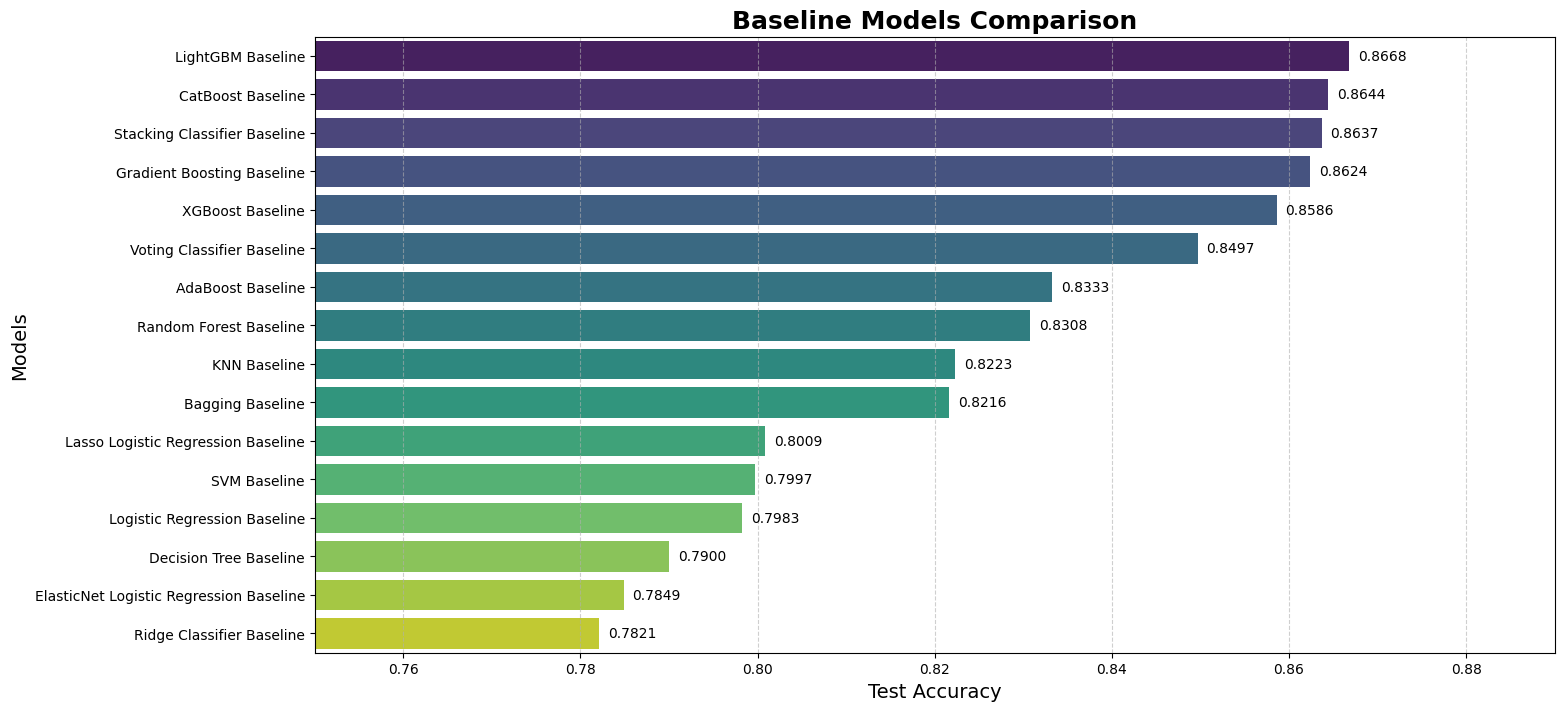

In [27]:
# =========================================================
# BASELINE MODEL ACCURACY COMPARISON
# =========================================================

# Sort dataframe by Test Accuracy
plot_df = baseline_model_results_df.sort_values(by='Test Accuracy', ascending=False)

# =========================================================
# CREATE FIGURE
# =========================================================

plt.figure(figsize=(16, 8))

# =========================================================
# CREATE BARPLOT
# =========================================================

sns.barplot(data=plot_df, x='Test Accuracy', y='Model', palette='viridis')

# =========================================================
# ADD TITLE
# =========================================================

plt.title('Baseline Models Comparison', fontsize=18, fontweight='bold')

# =========================================================
# X AND Y LABELS
# =========================================================

plt.xlabel('Test Accuracy', fontsize=14)

plt.ylabel('Models', fontsize=14)

# =========================================================
# X-AXIS LIMIT
# =========================================================

plt.xlim(0.75, 0.89)

# =========================================================
# SHOW GRID
# =========================================================

plt.grid(axis='x', linestyle='--', alpha=0.6)

# =========================================================
# SHOW VALUES ON BARS
# =========================================================

for index, value in enumerate(plot_df['Test Accuracy']):
    
    plt.text(value + 0.001, index, f'{value:.4f}', va='center', fontsize=10)

# =========================================================
# SHOW PLOT
# =========================================================

plt.show()

# Model 2 — After EDA

In [28]:
# =========================================================
# CREATE EDA DATAFRAME
# =========================================================

df_eda = df.copy()

print("EDA dataframe created successfully.")

EDA dataframe created successfully.


In [29]:
# =========================================================
# SEPARATE NUMERICAL & CATEGORICAL COLUMNS
# =========================================================

# Numerical Columns
numerical_columns = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical Columns
categorical_columns = df_eda.select_dtypes(include='object').columns.tolist()

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("Numerical Columns:\n")
print(numerical_columns)

print("\n")

print("Categorical Columns:\n")
print(categorical_columns)

Numerical Columns:

['age', 'capital_gain', 'capital_loss', 'hours_per_week']


Categorical Columns:

['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [30]:
# =========================================================
# DESCRIPTIVE STATISTICS
# =========================================================

df_eda[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,29096.0,39.251340,13.687157,17.0,28.0,38.0,48.0,90.0
capital_gain,29096.0,1197.802206,7778.225220,0.0,0.0,0.0,0.0,99999.0
capital_loss,29096.0,97.175179,424.008232,0.0,0.0,0.0,0.0,4356.0
hours_per_week,29096.0,40.637820,12.735418,1.0,40.0,40.0,45.0,99.0


In [31]:
# =========================================================
# CHECK SKEWNESS
# =========================================================

skewness_df = pd.DataFrame({

    'Feature': numerical_columns,

    'Skewness': [
        df_eda[column].skew()
        for column in numerical_columns
    ]
})

# Sort by highest skewness
skewness_df = skewness_df.sort_values(by='Skewness', ascending=False)

# Reset Index
skewness_df.reset_index(drop=True, inplace=True)

# Display
skewness_df

,Feature,Skewness
0,capital_gain,11.332823
1,capital_loss,4.321745
2,age,0.540444
3,hours_per_week,0.239739


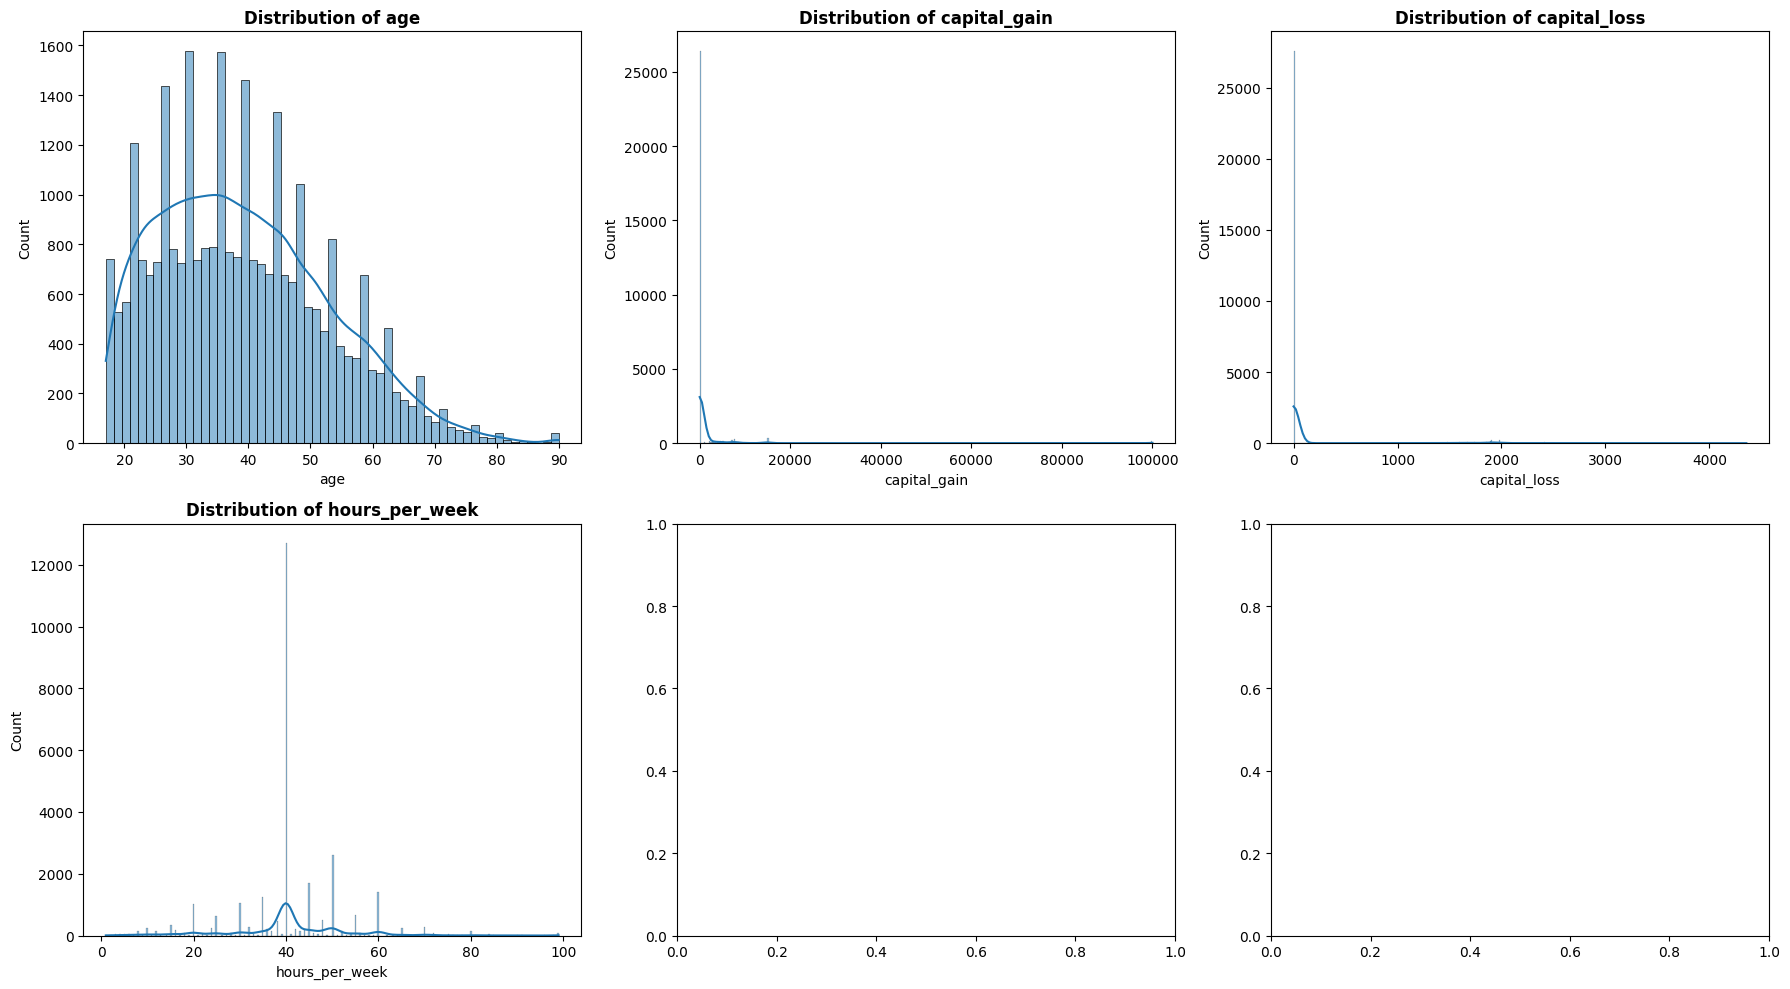

In [32]:
# =========================================================
# DISTRIBUTION PLOTS
# =========================================================

# Create Figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18,10))

# Flatten Axes
axes = axes.flatten()

# =========================================================
# LOOP THROUGH NUMERICAL COLUMNS
# =========================================================

for index, column in enumerate(numerical_columns):

    sns.histplot(data=df_eda, x=column, kde=True, ax=axes[index])

    axes[index].set_title(f"Distribution of {column}", fontsize=12, fontweight='bold')

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

# =========================================================
# SHOW PLOT
# =========================================================

plt.show()

In [33]:
# =========================================================
# APPLY LOG TRANSFORMATION
# =========================================================

# Apply log1p transformation
df_eda['capital_gain'] = np.log1p(df_eda['capital_gain'])

df_eda['capital_loss'] = np.log1p(df_eda['capital_loss'])

print("Log transformation applied successfully.")

Log transformation applied successfully.


In [34]:
# =========================================================
# CHECK SKEWNESS AFTER LOG TRANSFORMATION
# =========================================================

skewness_after_log_df = pd.DataFrame({

    'Feature': numerical_columns,

    'Skewness After Log Transformation': [
        df_eda[column].skew()
        for column in numerical_columns
    ]
})

# Sort by highest skewness
skewness_after_log_df = skewness_after_log_df.sort_values(by='Skewness After Log Transformation', ascending=False)

# Reset Index
skewness_after_log_df.reset_index(drop=True, inplace=True)

# Display
skewness_after_log_df

,Feature,Skewness After Log Transformation
0,capital_loss,4.046512
1,capital_gain,2.885416
2,age,0.540444
3,hours_per_week,0.239739


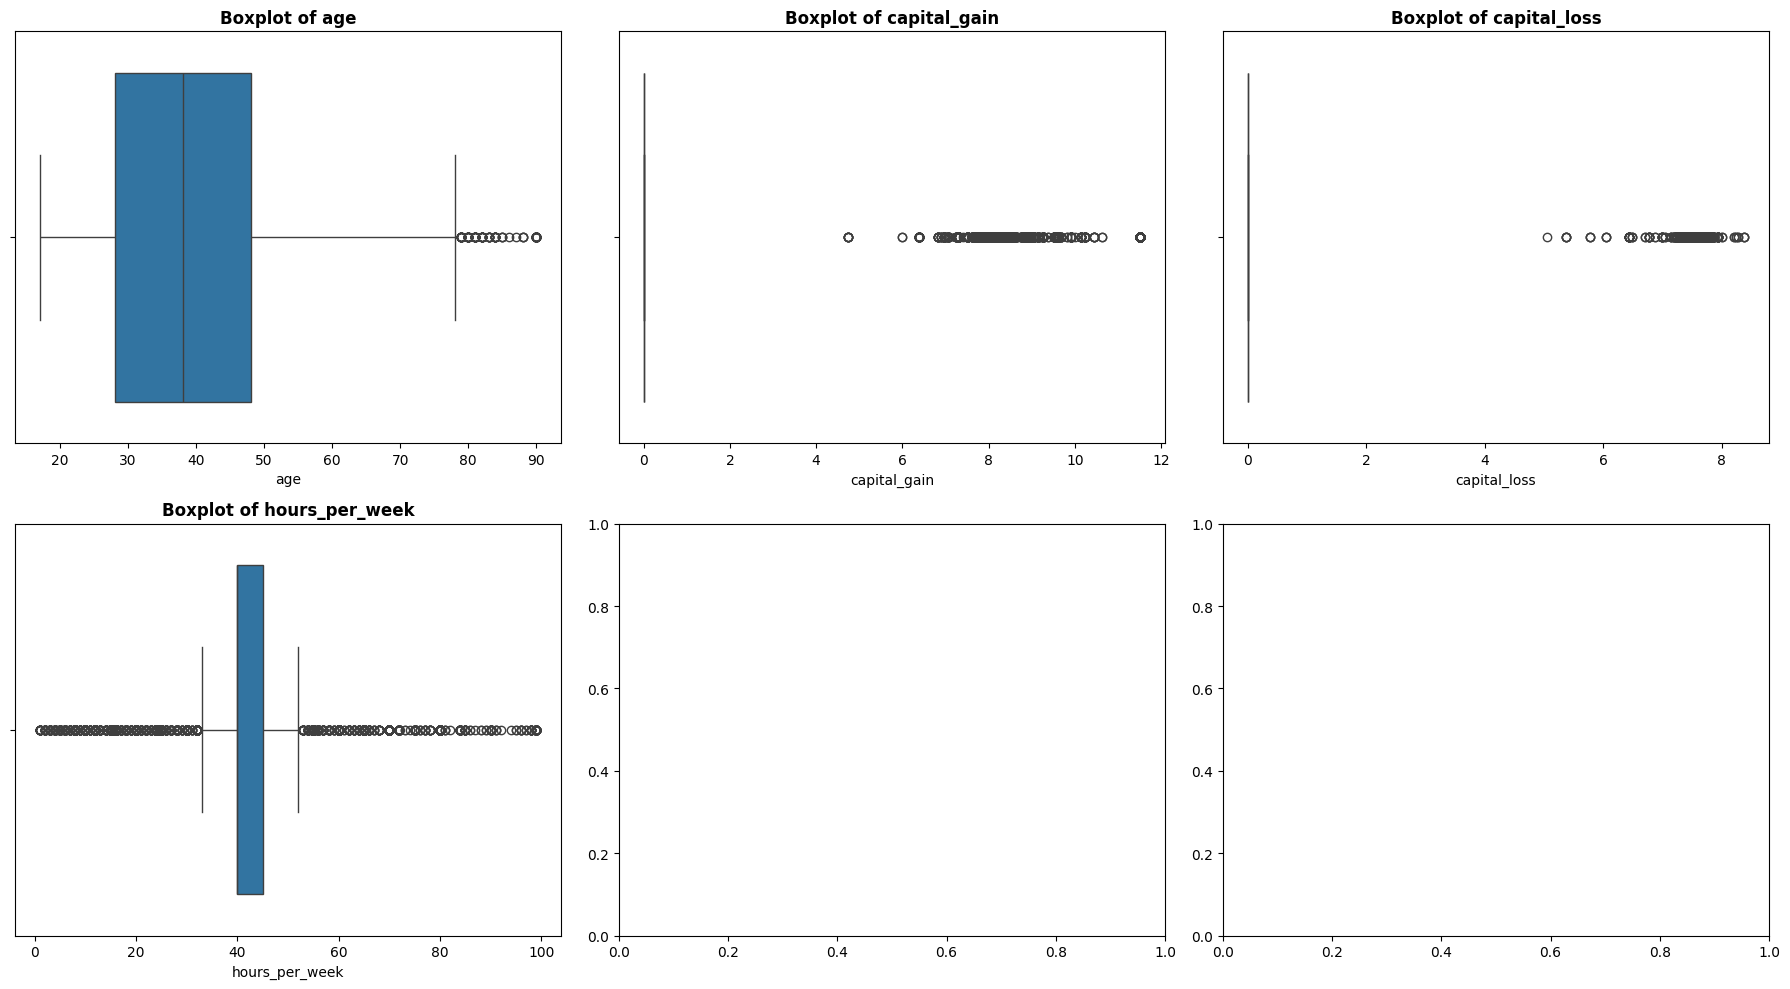

In [35]:
# =========================================================
# BOXPLOTS FOR OUTLIER DETECTION
# =========================================================

# Create Figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18,10))

# Flatten Axes
axes = axes.flatten()

# =========================================================
# LOOP THROUGH NUMERICAL FEATURES
# =========================================================

for index, column in enumerate(numerical_columns):

    sns.boxplot(x=df_eda[column], ax=axes[index])

    axes[index].set_title(f"Boxplot of {column}", fontsize=12, fontweight='bold')

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

# =========================================================
# SHOW PLOT
# =========================================================

plt.show()

In [36]:
# =========================================================
# CREATE COPY FOR SCALING
# =========================================================

df_eda_scaled = df_eda.copy()

# =========================================================
# INITIALIZE ROBUST SCALER
# =========================================================

scaler = RobustScaler()

# =========================================================
# SCALE NUMERICAL FEATURES
# =========================================================

df_eda_scaled[numerical_columns] = scaler.fit_transform(df_eda_scaled[numerical_columns])

print("Feature scaling applied successfully.")

Feature scaling applied successfully.


In [37]:
# =========================================================
# APPLY ONE-HOT ENCODING
# =========================================================

df_eda_encoded = pd.get_dummies(df_eda_scaled, drop_first=True)

print("One-Hot Encoding applied successfully.")

One-Hot Encoding applied successfully.


In [38]:
# =========================================================
# CHECK ENCODED DATASET SHAPE
# =========================================================

print("Encoded Dataset Shape :", df_eda_encoded.shape)

Encoded Dataset Shape : (29096, 96)


In [39]:
# =========================================================
# SEPARATE FEATURES & TARGET
# =========================================================

# Features
x_eda = df_eda_encoded.drop('income_ >50K', axis=1)

# Target
y_eda = df_eda_encoded['income_ >50K']

# =========================================================
# DISPLAY SHAPES
# =========================================================

print("x_eda Shape :", x_eda.shape)

print("y_eda Shape :", y_eda.shape)

x_eda Shape : (29096, 95)
y_eda Shape : (29096,)


In [40]:
# =========================================================
# TRAIN TEST SPLIT - MODEL 2
# =========================================================

x_train_eda, x_test_eda, y_train_eda, y_test_eda = train_test_split(

    x_eda,
    y_eda,

    test_size=0.20,

    random_state=10,

    stratify=y_eda
)

# =========================================================
# DISPLAY SHAPES
# =========================================================

print("x_train_eda Shape :", x_train_eda.shape)
print("x_test_eda Shape  :", x_test_eda.shape)
print("y_train_eda Shape :", y_train_eda.shape)
print("y_test_eda Shape  :", y_test_eda.shape)

x_train_eda Shape : (23276, 95)
x_test_eda Shape  : (5820, 95)
y_train_eda Shape : (23276,)
y_test_eda Shape  : (5820,)


In [41]:
# =========================================================
# MODEL 2 ALGORITHMS (AFTER EDA)
# =========================================================

eda_models = {

    # =====================================================
    # LINEAR MODELS
    # =====================================================

    "Logistic Regression EDA":
    LogisticRegression(
        max_iter=5000,
        random_state=10
    ),

    "Ridge Classifier EDA":
    RidgeClassifier(random_state=10),

    "Lasso Logistic Regression EDA":
    LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=5000,
        random_state=10
    ),

    "ElasticNet Logistic Regression EDA":
    LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        max_iter=5000,
        random_state=10
    ),

    # =====================================================
    # TREE MODELS
    # =====================================================

    "Decision Tree EDA":
    DecisionTreeClassifier(
        random_state=10
    ),

    "Random Forest EDA":
    RandomForestClassifier(
        random_state=10
    ),

    # =====================================================
    # BOOSTING MODELS
    # =====================================================

    "AdaBoost EDA":
    AdaBoostClassifier(
        random_state=10
    ),

    "Gradient Boosting EDA":
    GradientBoostingClassifier(
        random_state=10
    ),

    "XGBoost EDA":
    XGBClassifier(
        random_state=10,
        eval_metric='logloss'
    ),

    "LightGBM EDA":
    LGBMClassifier(
        random_state=10,
        verbose=-1
    ),

    "CatBoost EDA":
    CatBoostClassifier(
        random_state=10,
        verbose=0
    ),

    # =====================================================
    # OTHER MODELS
    # =====================================================

    "SVM EDA":
    SVC(
        random_state=10
    ),

    "KNN EDA":
    KNeighborsClassifier(),

    "Bagging EDA":
    BaggingClassifier(
        random_state=10
    )
}

# =========================================================
# VOTING CLASSIFIER
# =========================================================

voting_classifier_eda = VotingClassifier(

    estimators=[

        ('lr', LogisticRegression(
            max_iter=5000,
            random_state=10
        )),

        ('rf', RandomForestClassifier(
            random_state=10
        )),

        ('xgb', XGBClassifier(
            random_state=10,
            eval_metric='logloss'
        ))
    ],

    voting='hard'
)

# Add to Dictionary
eda_models["Voting Classifier EDA"] = voting_classifier_eda

# =========================================================
# STACKING CLASSIFIER
# =========================================================

stacking_classifier_eda = StackingClassifier(

    estimators=[

        ('rf', RandomForestClassifier(
            random_state=10
        )),

        ('xgb', XGBClassifier(
            random_state=10,
            eval_metric='logloss'
        )),

        ('lgbm', LGBMClassifier(
            random_state=10,
            verbose=-1
        ))
    ],

    final_estimator=LogisticRegression(
        max_iter=5000,
        random_state=10
    )
)

# Add to Dictionary
eda_models["Stacking Classifier EDA"] = stacking_classifier_eda

# =========================================================
# SUCCESS MESSAGE
# =========================================================

print("EDA models created successfully.")

EDA models created successfully.


In [42]:
# =========================================================
# MODEL 2 TRAINING & EVALUATION
# =========================================================

# Create Empty List
eda_model_results = []

# =========================================================
# LOOP THROUGH ALL MODELS
# =========================================================

for model_name, model in eda_models.items():

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    model.fit(x_train_eda, y_train_eda)

    # =====================================================
    # TRAIN PREDICTIONS
    # =====================================================

    y_train_pred_eda = model.predict(x_train_eda)

    # =====================================================
    # TEST PREDICTIONS
    # =====================================================

    y_test_pred_eda = model.predict(x_test_eda)

    # =====================================================
    # TRAIN ACCURACY
    # =====================================================

    train_accuracy = accuracy_score(
        y_train_eda,
        y_train_pred_eda
    )

    # =====================================================
    # TEST ACCURACY
    # =====================================================

    test_accuracy = accuracy_score(
        y_test_eda,
        y_test_pred_eda
    )

    # =====================================================
    # PRECISION
    # =====================================================

    precision = precision_score(
        y_test_eda,
        y_test_pred_eda
    )

    # =====================================================
    # RECALL
    # =====================================================

    recall = recall_score(
        y_test_eda,
        y_test_pred_eda
    )

    # =====================================================
    # F1 SCORE
    # =====================================================

    f1 = f1_score(
        y_test_eda,
        y_test_pred_eda
    )

    # =====================================================
    # STORE RESULTS
    # =====================================================

    eda_model_results.append({

        "Model": model_name,

        "Train Accuracy": round(train_accuracy, 4),

        "Test Accuracy": round(test_accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1 Score": round(f1, 4)
    })

# =========================================================
# CREATE DATAFRAME
# =========================================================

eda_model_results_df = pd.DataFrame(
    eda_model_results
)

# =========================================================
# SORT BY TEST ACCURACY
# =========================================================

eda_model_results_df = eda_model_results_df.sort_values(
    by='Test Accuracy',
    ascending=False
)

# Reset Index
eda_model_results_df.reset_index(
    drop=True,
    inplace=True
)

# =========================================================
# DISPLAY RESULTS
# =========================================================

eda_model_results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Stacking Classifier EDA,0.8705,0.8663,0.7639,0.6664,0.7119
1,LightGBM EDA,0.8839,0.8637,0.7586,0.6602,0.7060
2,CatBoost EDA,0.8915,0.8622,0.7597,0.6491,0.7001
3,XGBoost EDA,0.8929,0.8608,0.7469,0.6630,0.7024
4,Gradient Boosting EDA,0.8633,0.8603,0.7926,0.5908,0.6770
5,Voting Classifier EDA,0.9066,0.8570,0.7488,0.6366,0.6882
6,SVM EDA,0.8516,0.8462,0.7583,0.5569,0.6421
7,AdaBoost EDA,0.8417,0.8414,0.7227,0.5839,0.6460
8,Lasso Logistic Regression EDA,0.8404,0.8344,0.6962,0.5881,0.6376
9,ElasticNet Logistic Regression EDA,0.8406,0.8344,0.6965,0.5874,0.6373


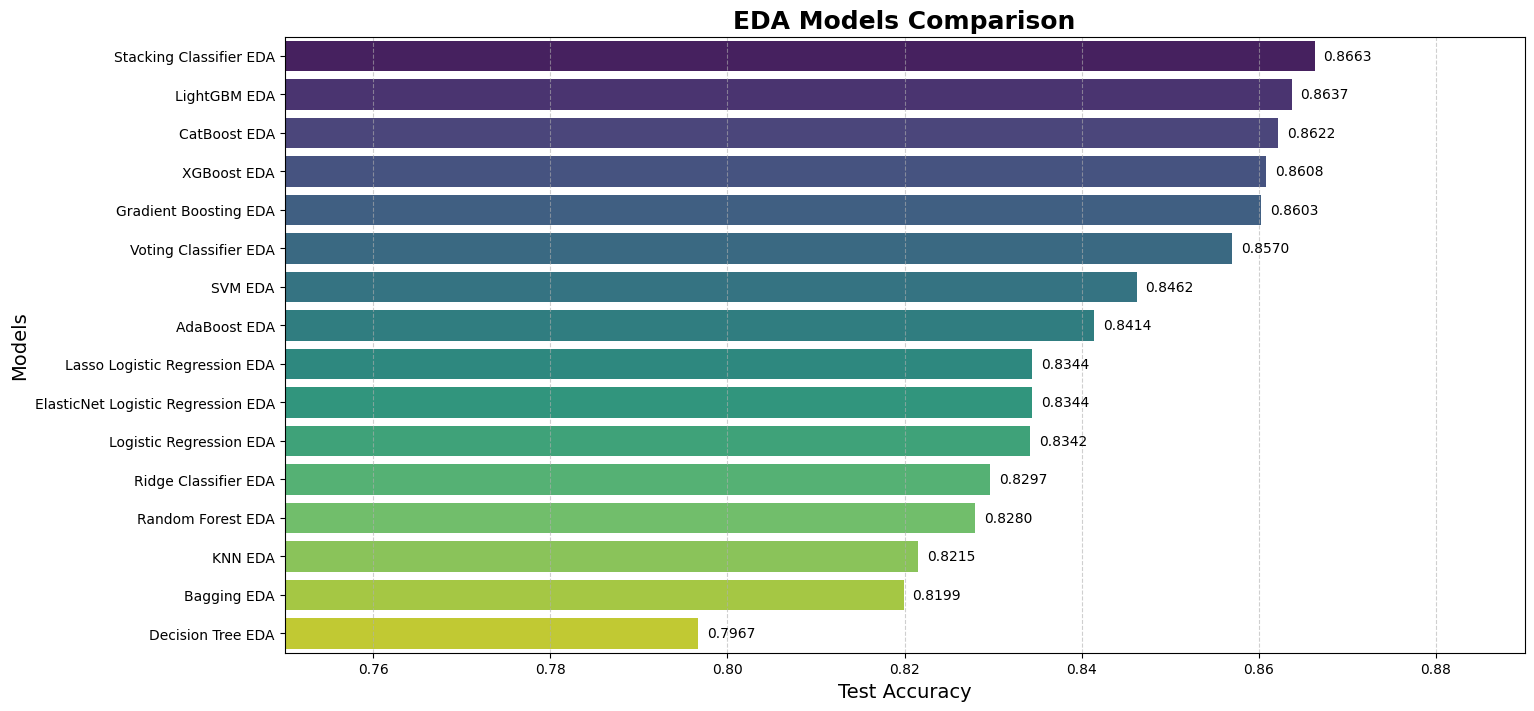

In [43]:
# =========================================================
# EDA MODEL ACCURACY COMPARISON
# =========================================================

# Sort dataframe by Test Accuracy
plot_df = eda_model_results_df.sort_values(

    by='Test Accuracy',
    ascending=False
)

# =========================================================
# CREATE FIGURE
# =========================================================

plt.figure(figsize=(16, 8))

# =========================================================
# CREATE BARPLOT
# =========================================================

sns.barplot(

    data=plot_df,

    x='Test Accuracy',
    y='Model',

    palette='viridis'
)

# =========================================================
# ADD TITLE
# =========================================================

plt.title(

    'EDA Models Comparison',
    
    fontsize=18,
    
    fontweight='bold'
)

# =========================================================
# X AND Y LABELS
# =========================================================

plt.xlabel(

    'Test Accuracy',
    
    fontsize=14
)

plt.ylabel(

    'Models',
    
    fontsize=14
)

# =========================================================
# X-AXIS LIMIT
# =========================================================

plt.xlim(0.75, 0.89)

# =========================================================
# SHOW GRID
# =========================================================

plt.grid(

    axis='x',
    
    linestyle='--',
    
    alpha=0.6
)

# =========================================================
# SHOW VALUES ON BARS
# =========================================================

for index, value in enumerate(
    
    plot_df['Test Accuracy']
):
    
    plt.text(
        
        value + 0.001,
        
        index,
        
        f'{value:.4f}',
        
        va='center',
        
        fontsize=10
    )

# =========================================================
# SHOW PLOT
# =========================================================

plt.show()

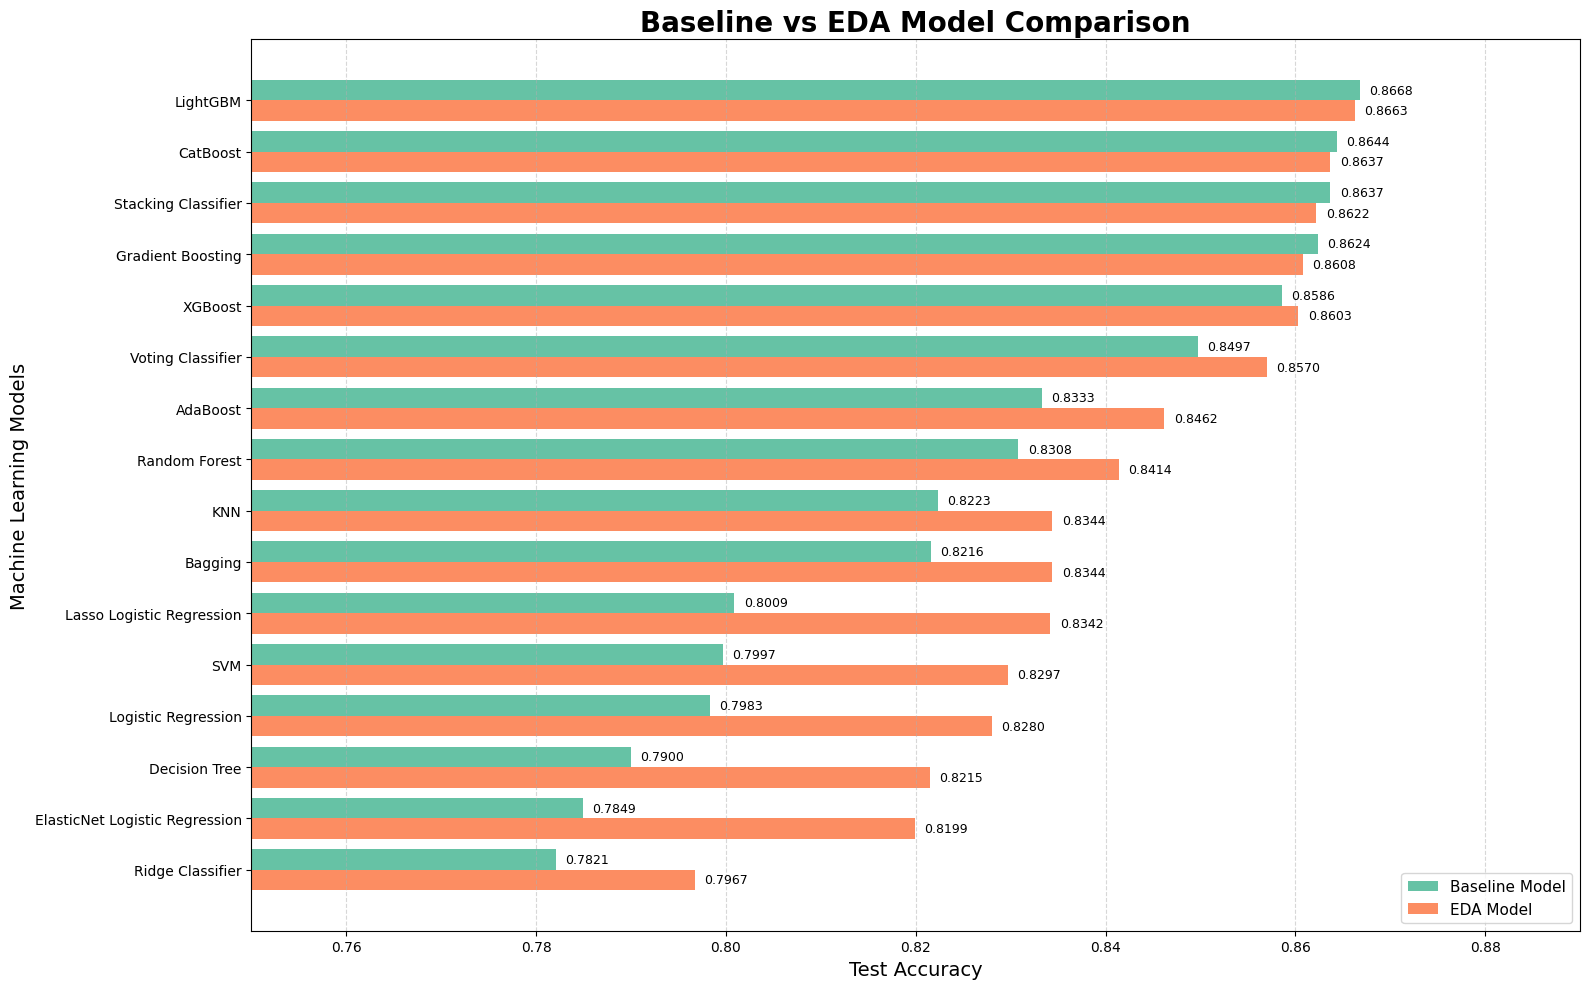

In [44]:
# =========================================================
# CREATE COMPARISON DATAFRAME
# =========================================================

comparison_df = pd.DataFrame({

    'Model':

    baseline_model_results_df['Model']
    .str.replace(' Baseline', '', regex=False),

    'Baseline Accuracy':
    baseline_model_results_df['Test Accuracy'].values,

    'EDA Accuracy':
    eda_model_results_df['Test Accuracy'].values
})

# =========================================================
# SORT BY EDA ACCURACY
# =========================================================

comparison_df = comparison_df.sort_values(

    by='EDA Accuracy',
    ascending=True
)

# =========================================================
# CREATE FIGURE
# =========================================================

plt.figure(figsize=(16, 10))

# =========================================================
# BAR WIDTH
# =========================================================

bar_width = 0.4

# =========================================================
# POSITIONS
# =========================================================

y_positions = np.arange(len(comparison_df))

# =========================================================
# BASELINE BARS
# =========================================================

baseline_bars = plt.barh(

    y_positions + bar_width/2,

    comparison_df['Baseline Accuracy'],

    height=bar_width,

    label='Baseline Model',

    color='#66c2a5'
)

# =========================================================
# EDA BARS
# =========================================================

eda_bars = plt.barh(

    y_positions - bar_width/2,

    comparison_df['EDA Accuracy'],

    height=bar_width,

    label='EDA Model',

    color='#fc8d62'
)

# =========================================================
# ADD ACCURACY LABELS
# =========================================================

for bars in [baseline_bars, eda_bars]:
    
    for bar in bars:
        
        width = bar.get_width()
        
        plt.text(
            
            width + 0.001,
            
            bar.get_y() + bar.get_height()/2,
            
            f'{width:.4f}',
            
            va='center',
            
            fontsize=9
        )

# =========================================================
# LABELS
# =========================================================

plt.yticks(

    y_positions,

    comparison_df['Model']
)

plt.xlabel(

    "Test Accuracy",
    
    fontsize=14
)

plt.ylabel(

    "Machine Learning Models",
    
    fontsize=14
)

# =========================================================
# TITLE
# =========================================================

plt.title(

    "Baseline vs EDA Model Comparison",
    
    fontsize=20,
    
    fontweight='bold'
)

# =========================================================
# X-AXIS LIMIT
# =========================================================

plt.xlim(0.75, 0.89)

# =========================================================
# LEGEND
# =========================================================

plt.legend(

    fontsize=11
)

# =========================================================
# GRID
# =========================================================

plt.grid(

    axis='x',
    
    linestyle='--',
    
    alpha=0.5
)

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

# =========================================================
# SHOW PLOT
# =========================================================

plt.show()

# Model 3 — Hyperparameter Tuning

In [45]:
# =========================================================
# CREATE TUNED DATASET
# =========================================================

x_tuned = x_eda.copy()

y_tuned = y_eda.copy()

print("Tuned dataset created successfully.")

Tuned dataset created successfully.


In [46]:
# =========================================================
# LOGISTIC REGRESSION HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
logistic_params = {

    'C': [0.001, 0.01, 0.1, 1, 10, 100],

    'solver': ['liblinear', 'lbfgs'],

    'penalty': ['l2']
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

logistic_random_search = RandomizedSearchCV(

    estimator=LogisticRegression(
        max_iter=5000,
        random_state=10
    ),

    param_distributions=logistic_params,

    n_iter=10,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

logistic_random_search.fit(
    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(logistic_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(logistic_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'solver': 'lbfgs', 'penalty': 'l2', 'C': 100}

Best Cross Validation Score :
0.8386320920120627


In [47]:
# =========================================================
# BEST LOGISTIC REGRESSION MODEL
# =========================================================

best_logistic_model = logistic_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_logistic = best_logistic_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_logistic = best_logistic_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_logistic
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_logistic
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_logistic
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_logistic
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_logistic
)

# =========================================================
# DISPLAY RESULTS
# =========================================================

logistic_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

logistic_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8407
1,Test Accuracy,0.8335
2,Precision,0.6927
3,Recall,0.5895
4,F1 Score,0.6369


In [48]:
# =========================================================
# RIDGE CLASSIFIER HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
ridge_params = {

    'alpha': [

        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    'solver': [

        'auto',
        'svd',
        'cholesky',
        'lsqr',
        'sag'
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

ridge_random_search = RandomizedSearchCV(

    estimator=RidgeClassifier(),

    param_distributions=ridge_params,

    n_iter=10,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

ridge_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(ridge_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(ridge_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'solver': 'lsqr', 'alpha': 0.001}

Best Cross Validation Score :
0.8349801602681224


In [49]:
# =========================================================
# BEST RIDGE CLASSIFIER MODEL
# =========================================================

best_ridge_model = ridge_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_ridge = best_ridge_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_ridge = best_ridge_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_ridge
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_ridge
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_ridge
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_ridge
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_ridge
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

ridge_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

ridge_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8365
1,Test Accuracy,0.8292
2,Precision,0.7196
3,Recall,0.5090
4,F1 Score,0.5963


In [50]:
# =========================================================
# LASSO LOGISTIC REGRESSION HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
lasso_params = {

    'C': [

        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    'solver': [

        'liblinear',
        'saga'
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

lasso_random_search = RandomizedSearchCV(

    estimator=LogisticRegression(

        penalty='l1',

        max_iter=5000,

        random_state=10
    ),

    param_distributions=lasso_params,

    n_iter=10,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

lasso_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(lasso_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(lasso_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'solver': 'liblinear', 'C': 1}

Best Cross Validation Score :
0.8383313032212343


In [51]:
# =========================================================
# BEST LASSO LOGISTIC REGRESSION MODEL
# =========================================================

best_lasso_model = lasso_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_lasso = best_lasso_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_lasso = best_lasso_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_lasso
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_lasso
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_lasso
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_lasso
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_lasso
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

lasso_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

lasso_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8404
1,Test Accuracy,0.8344
2,Precision,0.6962
3,Recall,0.5881
4,F1 Score,0.6376


In [52]:
# =========================================================
# ELASTICNET LOGISTIC REGRESSION HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
elasticnet_params = {

    'C': [

        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    'l1_ratio': [

        0.1,
        0.3,
        0.5,
        0.7,
        0.9
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

elasticnet_random_search = RandomizedSearchCV(

    estimator=LogisticRegression(

        penalty='elasticnet',

        solver='saga',

        max_iter=5000,

        random_state=10
    ),

    param_distributions=elasticnet_params,

    n_iter=10,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

elasticnet_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(elasticnet_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(elasticnet_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'l1_ratio': 0.1, 'C': 10}

Best Cross Validation Score :
0.8381594819153924


In [53]:
# =========================================================
# BEST ELASTICNET MODEL
# =========================================================

best_elasticnet_model = elasticnet_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_elasticnet = best_elasticnet_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_elasticnet = best_elasticnet_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_elasticnet
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_elasticnet
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_elasticnet
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_elasticnet
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_elasticnet
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

elasticnet_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

elasticnet_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8406
1,Test Accuracy,0.8333
2,Precision,0.6925
3,Recall,0.5888
4,F1 Score,0.6364


In [54]:
# =========================================================
# DECISION TREE HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
decision_tree_params = {

    'criterion': [

        'gini',
        'entropy'
    ],

    'max_depth': [

        3,
        5,
        10,
        15,
        20,
        None
    ],

    'min_samples_split': [

        2,
        5,
        10,
        20
    ],

    'min_samples_leaf': [

        1,
        2,
        5,
        10
    ],

    'max_features': [

        'sqrt',
        'log2',
        None
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

decision_tree_random_search = RandomizedSearchCV(

    estimator=DecisionTreeClassifier(
        random_state=10
    ),

    param_distributions=decision_tree_params,

    n_iter=20,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

decision_tree_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(decision_tree_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(decision_tree_random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters :
{'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 10, 'criterion': 'entropy'}

Best Cross Validation Score :
0.8483845198415775


In [55]:
# =========================================================
# BEST DECISION TREE MODEL
# =========================================================

best_decision_tree_model = decision_tree_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_decision_tree = best_decision_tree_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_decision_tree = best_decision_tree_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_decision_tree
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_decision_tree
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_decision_tree
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_decision_tree
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_decision_tree
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

decision_tree_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

decision_tree_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8609
1,Test Accuracy,0.8474
2,Precision,0.7456
3,Recall,0.5832
4,F1 Score,0.6545


In [56]:
# =========================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
random_forest_params = {

    'n_estimators': [

        100,
        200,
        300
    ],

    'max_depth': [

        5,
        10,
        15,
        20,
        None
    ],

    'min_samples_split': [

        2,
        5,
        10
    ],

    'min_samples_leaf': [

        1,
        2,
        4
    ],

    'max_features': [

        'sqrt',
        'log2'
    ],

    'bootstrap': [

        True,
        False
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

random_forest_random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(
        random_state=10
    ),

    param_distributions=random_forest_params,

    n_iter=20,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

random_forest_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(random_forest_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(random_forest_random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters :
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}

Best Cross Validation Score :
0.8582660166616837


In [57]:
# =========================================================
# BEST RANDOM FOREST MODEL
# =========================================================

best_random_forest_model = random_forest_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_random_forest = best_random_forest_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_random_forest = best_random_forest_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_random_forest
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_random_forest
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_random_forest
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_random_forest
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_random_forest
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

random_forest_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

random_forest_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8935
1,Test Accuracy,0.8553
2,Precision,0.7747
3,Recall,0.5867
4,F1 Score,0.6677


In [58]:
# =========================================================
# ADABOOST HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
adaboost_params = {

    'n_estimators': [

        50,
        100,
        200,
        300
    ],

    'learning_rate': [

        0.001,
        0.01,
        0.1,
        0.5,
        1
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

adaboost_random_search = RandomizedSearchCV(

    estimator=AdaBoostClassifier(
        random_state=10
    ),

    param_distributions=adaboost_params,

    n_iter=10,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

adaboost_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(adaboost_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(adaboost_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'n_estimators': 200, 'learning_rate': 0.5}

Best Cross Validation Score :
0.8485992411071862


In [59]:
# =========================================================
# BEST ADABOOST MODEL
# =========================================================

best_adaboost_model = adaboost_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_adaboost = best_adaboost_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_adaboost = best_adaboost_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_adaboost
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_adaboost
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_adaboost
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_adaboost
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_adaboost
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

adaboost_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

adaboost_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8494
1,Test Accuracy,0.8495
2,Precision,0.8050
3,Recall,0.5180
4,F1 Score,0.6304


In [60]:
# =========================================================
# GRADIENT BOOSTING HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
gradient_boosting_params = {

    'n_estimators': [

        100,
        200,
        300
    ],

    'learning_rate': [

        0.01,
        0.05,
        0.1,
        0.2
    ],

    'max_depth': [

        3,
        5,
        7
    ],

    'min_samples_split': [

        2,
        5,
        10
    ],

    'min_samples_leaf': [

        1,
        2,
        4
    ],

    'subsample': [

        0.8,
        0.9,
        1.0
    ],

    'max_features': [

        'sqrt',
        'log2',
        None
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

gradient_boosting_random_search = RandomizedSearchCV(

    estimator=GradientBoostingClassifier(
        random_state=10
    ),

    param_distributions=gradient_boosting_params,

    n_iter=20,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

gradient_boosting_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(gradient_boosting_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(gradient_boosting_random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters :
{'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.2}

Best Cross Validation Score :
0.8679325707494068


In [61]:
# =========================================================
# BEST GRADIENT BOOSTING MODEL
# =========================================================

best_gradient_boosting_model = gradient_boosting_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_gradient_boosting = best_gradient_boosting_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_gradient_boosting = best_gradient_boosting_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_gradient_boosting
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_gradient_boosting
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_gradient_boosting
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_gradient_boosting
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_gradient_boosting
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

gradient_boosting_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

gradient_boosting_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8848
1,Test Accuracy,0.8632
2,Precision,0.7592
3,Recall,0.6560
4,F1 Score,0.7039


In [62]:
# =========================================================
# XGBOOST HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
xgboost_params = {

    'n_estimators': [

        100,
        200,
        300
    ],

    'learning_rate': [

        0.01,
        0.05,
        0.1,
        0.2
    ],

    'max_depth': [

        3,
        5,
        7,
        10
    ],

    'min_child_weight': [

        1,
        3,
        5
    ],

    'subsample': [

        0.8,
        0.9,
        1.0
    ],

    'colsample_bytree': [

        0.8,
        0.9,
        1.0
    ],

    'gamma': [

        0,
        0.1,
        0.3,
        0.5
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

xgboost_random_search = RandomizedSearchCV(

    estimator=XGBClassifier(

        random_state=10,

        use_label_encoder=False,

        eval_metric='logloss'
    ),

    param_distributions=xgboost_params,

    n_iter=20,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

xgboost_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(xgboost_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(xgboost_random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters :
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}

Best Cross Validation Score :
0.8698658557291609


In [63]:
# =========================================================
# BEST XGBOOST MODEL
# =========================================================

best_xgboost_model = xgboost_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_xgboost = best_xgboost_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_xgboost = best_xgboost_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_xgboost
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_xgboost
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_xgboost
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_xgboost
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_xgboost
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

xgboost_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

xgboost_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8891
1,Test Accuracy,0.8627
2,Precision,0.7591
3,Recall,0.6533
4,F1 Score,0.7022


In [64]:
# =========================================================
# LIGHTGBM HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
lightgbm_params = {

    'n_estimators': [

        100,
        200,
        300
    ],

    'learning_rate': [

        0.01,
        0.05,
        0.1,
        0.2
    ],

    'max_depth': [

        -1,
        5,
        10,
        15
    ],

    'num_leaves': [

        20,
        31,
        50,
        70
    ],

    'min_child_samples': [

        10,
        20,
        30
    ],

    'subsample': [

        0.8,
        0.9,
        1.0
    ],

    'colsample_bytree': [

        0.8,
        0.9,
        1.0
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

lightgbm_random_search = RandomizedSearchCV(

    estimator=LGBMClassifier(
        random_state=10
    ),

    param_distributions=lightgbm_params,

    n_iter=20,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

lightgbm_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(lightgbm_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(lightgbm_random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters :
{'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best Cross Validation Score :
0.8690496860708473


In [65]:
# =========================================================
# BEST LIGHTGBM MODEL
# =========================================================

best_lightgbm_model = lightgbm_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_lightgbm = best_lightgbm_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_lightgbm = best_lightgbm_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_lightgbm
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_lightgbm
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_lightgbm
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_lightgbm
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_lightgbm
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

lightgbm_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

lightgbm_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8868
1,Test Accuracy,0.8625
2,Precision,0.7572
3,Recall,0.6553
4,F1 Score,0.7026


In [66]:
# =========================================================
# CATBOOST HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
catboost_params = {

    'iterations': [

        100,
        200,
        300
    ],

    'learning_rate': [

        0.01,
        0.05,
        0.1,
        0.2
    ],

    'depth': [

        4,
        6,
        8,
        10
    ],

    'l2_leaf_reg': [

        1,
        3,
        5,
        7,
        9
    ],

    'border_count': [

        32,
        64,
        128
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

catboost_random_search = RandomizedSearchCV(

    estimator=CatBoostClassifier(

        random_state=10,

        verbose=0
    ),

    param_distributions=catboost_params,

    n_iter=20,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

catboost_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(catboost_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(catboost_random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters :
{'learning_rate': 0.2, 'l2_leaf_reg': 9, 'iterations': 200, 'depth': 6, 'border_count': 128}

Best Cross Validation Score :
0.868791834150915


In [67]:
# =========================================================
# BEST CATBOOST MODEL
# =========================================================

best_catboost_model = catboost_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_catboost = best_catboost_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_catboost = best_catboost_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_catboost
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_catboost
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_catboost
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_catboost
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_catboost
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

catboost_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

catboost_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8874
1,Test Accuracy,0.8631
2,Precision,0.7641
3,Recall,0.6470
4,F1 Score,0.7007


In [68]:
# =========================================================
# SVM HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
svm_params = {

    'C': [

        0.01,
        0.1,
        1,
        10,
        100
    ],

    'kernel': [

        'linear',
        'rbf'
    ],

    'gamma': [

        'scale',
        'auto'
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

svm_random_search = RandomizedSearchCV(

    estimator=SVC(
        random_state=10
    ),

    param_distributions=svm_params,

    n_iter=10,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

svm_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(svm_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(svm_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'kernel': 'rbf', 'gamma': 'scale', 'C': 10}

Best Cross Validation Score :
0.845548896172685


In [69]:
# =========================================================
# BEST SVM MODEL
# =========================================================

best_svm_model = svm_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_svm = best_svm_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_svm = best_svm_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_svm
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_svm
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_svm
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_svm
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_svm
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

svm_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

svm_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8696
1,Test Accuracy,0.8502
2,Precision,0.7440
3,Recall,0.6026
4,F1 Score,0.6659


In [70]:
# =========================================================
# KNN HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
knn_params = {

    'n_neighbors': [

        3,
        5,
        7,
        9,
        11,
        15,
        21
    ],

    'weights': [

        'uniform',
        'distance'
    ],

    'metric': [

        'euclidean',
        'manhattan',
        'minkowski'
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

knn_random_search = RandomizedSearchCV(

    estimator=KNeighborsClassifier(),

    param_distributions=knn_params,

    n_iter=15,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

knn_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(knn_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(knn_random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters :
{'weights': 'uniform', 'n_neighbors': 21, 'metric': 'manhattan'}

Best Cross Validation Score :
0.8357104746402086


In [71]:
# =========================================================
# BEST KNN MODEL
# =========================================================

best_knn_model = knn_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_knn = best_knn_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_knn = best_knn_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_knn
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_knn
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_knn
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_knn
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_knn
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

knn_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

knn_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8527
1,Test Accuracy,0.8309
2,Precision,0.6689
3,Recall,0.6290
4,F1 Score,0.6483


In [72]:
# =========================================================
# BAGGING CLASSIFIER HYPERPARAMETER TUNING
# =========================================================

# Parameter Grid
bagging_params = {

    'n_estimators': [

        50,
        100,
        200,
        300
    ],

    'max_samples': [

        0.5,
        0.7,
        1.0
    ],

    'max_features': [

        0.5,
        0.7,
        1.0
    ],

    'bootstrap': [

        True,
        False
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

bagging_random_search = RandomizedSearchCV(

    estimator=BaggingClassifier(
        random_state=10
    ),

    param_distributions=bagging_params,

    n_iter=15,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

bagging_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(bagging_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(bagging_random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters :
{'n_estimators': 300, 'max_samples': 0.5, 'max_features': 0.5, 'bootstrap': False}

Best Cross Validation Score :
0.8586097054122789


In [73]:
# =========================================================
# BEST BAGGING MODEL
# =========================================================

best_bagging_model = bagging_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_bagging = best_bagging_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_bagging = best_bagging_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_bagging
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_bagging
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_bagging
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_bagging
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_bagging
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

bagging_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

bagging_tuned_results_df

,Metric,Score
0,Train Accuracy,0.9279
1,Test Accuracy,0.8545
2,Precision,0.7815
3,Recall,0.5728
4,F1 Score,0.6611


In [74]:
# =========================================================
# Voting Classifier Hyperparameter Tuning
# =========================================================

voting_lr = LogisticRegression(
    random_state=10,
    max_iter=1000
)

voting_rf = RandomForestClassifier(
    random_state=10
)

voting_gb = GradientBoostingClassifier(
    random_state=10
)

# =========================================================
# CREATE VOTING CLASSIFIER
# =========================================================

voting_classifier = VotingClassifier(

    estimators=[

        ('lr', voting_lr),
        ('rf', voting_rf),
        ('gb', voting_gb)
    ]
)

# =========================================================
# PARAMETER GRID
# =========================================================

voting_params = {

    'voting': [

        'hard',
        'soft'
    ],

    'weights': [

        [1,1,1],
        [1,2,2],
        [2,1,2],
        [2,2,1],
        [1,3,3]
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

voting_random_search = RandomizedSearchCV(

    estimator=voting_classifier,

    param_distributions=voting_params,

    n_iter=10,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

voting_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(voting_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(voting_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'weights': [1, 1, 1], 'voting': 'hard'}

Best Cross Validation Score :
0.8590823985589896


In [75]:
# =========================================================
# BEST VOTING CLASSIFIER MODEL
# =========================================================

best_voting_model = voting_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_voting = best_voting_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_voting = best_voting_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_voting
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_voting
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_voting
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_voting
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_voting
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

voting_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

voting_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8835
1,Test Accuracy,0.8565
2,Precision,0.7722
3,Recall,0.5971
4,F1 Score,0.6734


In [76]:
# =========================================================
# Stacking Classifier Hyperparameter Tuning
# =========================================================

stack_lr = LogisticRegression(
    random_state=10,
    max_iter=1000
)

stack_rf = RandomForestClassifier(
    random_state=10
)

stack_gb = GradientBoostingClassifier(
    random_state=10
)

# =========================================================
# CREATE STACKING CLASSIFIER
# =========================================================

stacking_classifier = StackingClassifier(

    estimators=[

        ('lr', stack_lr),
        ('rf', stack_rf),
        ('gb', stack_gb)
    ],

    final_estimator=LogisticRegression(random_state=10),

    cv=5
)

# =========================================================
# PARAMETER GRID
# =========================================================

stacking_params = {

    'final_estimator__C': [

        0.01,
        0.1,
        1,
        10
    ],

    'passthrough': [

        True,
        False
    ]
}

# =========================================================
# RANDOMIZED SEARCH
# =========================================================

stacking_random_search = RandomizedSearchCV(

    estimator=stacking_classifier,

    param_distributions=stacking_params,

    n_iter=8,

    scoring='accuracy',

    cv=5,

    verbose=1,

    random_state=10,

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

stacking_random_search.fit(

    x_train_eda,
    y_train_eda
)

# =========================================================
# BEST PARAMETERS
# =========================================================

print("Best Parameters :")

print(stacking_random_search.best_params_)

print()

# =========================================================
# BEST SCORE
# =========================================================

print("Best Cross Validation Score :")

print(stacking_random_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters :
{'passthrough': True, 'final_estimator__C': 1}

Best Cross Validation Score :
0.8635933168709699


In [77]:
# =========================================================
# BEST STACKING MODEL
# =========================================================

best_stacking_model = stacking_random_search.best_estimator_

# =========================================================
# TRAIN PREDICTIONS
# =========================================================

y_train_pred_stacking = best_stacking_model.predict(
    x_train_eda
)

# =========================================================
# TEST PREDICTIONS
# =========================================================

y_test_pred_stacking = best_stacking_model.predict(
    x_test_eda
)

# =========================================================
# TRAIN ACCURACY
# =========================================================

train_accuracy = accuracy_score(
    y_train_eda,
    y_train_pred_stacking
)

# =========================================================
# TEST ACCURACY
# =========================================================

test_accuracy = accuracy_score(
    y_test_eda,
    y_test_pred_stacking
)

# =========================================================
# PRECISION
# =========================================================

precision = precision_score(
    y_test_eda,
    y_test_pred_stacking
)

# =========================================================
# RECALL
# =========================================================

recall = recall_score(
    y_test_eda,
    y_test_pred_stacking
)

# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(
    y_test_eda,
    y_test_pred_stacking
)

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

stacking_tuned_results_df = pd.DataFrame({

    'Metric': [

        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],

    'Score': [

        round(train_accuracy, 4),

        round(test_accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4)
    ]
})

# =========================================================
# DISPLAY RESULTS
# =========================================================

stacking_tuned_results_df

,Metric,Score
0,Train Accuracy,0.8573
1,Test Accuracy,0.8622
2,Precision,0.7640
3,Recall,0.6422
4,F1 Score,0.6978


In [78]:
# =========================================================
# ADD MODEL NAMES TO EACH TUNED RESULTS DATAFRAME
# =========================================================

logistic_tuned_results_df['Model'] = 'Logistic Regression Tuned'

ridge_tuned_results_df['Model'] = 'Ridge Classifier Tuned'

lasso_tuned_results_df['Model'] = 'Lasso Logistic Regression Tuned'

elasticnet_tuned_results_df['Model'] = 'ElasticNet Logistic Regression Tuned'

decision_tree_tuned_results_df['Model'] = 'Decision Tree Tuned'

random_forest_tuned_results_df['Model'] = 'Random Forest Tuned'

adaboost_tuned_results_df['Model'] = 'AdaBoost Tuned'

gradient_boosting_tuned_results_df['Model'] = 'Gradient Boosting Tuned'

xgboost_tuned_results_df['Model'] = 'XGBoost Tuned'

lightgbm_tuned_results_df['Model'] = 'LightGBM Tuned'

catboost_tuned_results_df['Model'] = 'CatBoost Tuned'

svm_tuned_results_df['Model'] = 'SVM Tuned'

knn_tuned_results_df['Model'] = 'KNN Tuned'

bagging_tuned_results_df['Model'] = 'Bagging Tuned'

voting_tuned_results_df['Model'] = 'Voting Classifier Tuned'

stacking_tuned_results_df['Model'] = 'Stacking Classifier Tuned'

print("Model names added successfully.")

Model names added successfully.


In [79]:
# =========================================================
# COMBINE ALL TUNED RESULTS DATAFRAMES
# =========================================================

tuned_model_results_df = pd.concat([

    logistic_tuned_results_df,
    ridge_tuned_results_df,
    lasso_tuned_results_df,
    elasticnet_tuned_results_df,
    decision_tree_tuned_results_df,
    random_forest_tuned_results_df,
    adaboost_tuned_results_df,
    gradient_boosting_tuned_results_df,
    xgboost_tuned_results_df,
    lightgbm_tuned_results_df,
    catboost_tuned_results_df,
    svm_tuned_results_df,
    knn_tuned_results_df,
    bagging_tuned_results_df,
    voting_tuned_results_df,
    stacking_tuned_results_df

], ignore_index=True)

# =========================================================
# TRANSPOSE METRICS INTO COLUMNS
# =========================================================

tuned_model_results_df = tuned_model_results_df.pivot_table(

    index='Model',
    columns='Metric',
    values='Score'
).reset_index()

# =========================================================
# REORDER COLUMNS
# =========================================================

tuned_model_results_df = tuned_model_results_df[[
    
    'Model',
    'Train Accuracy',
    'Test Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]]

# =========================================================
# SORT BY TEST ACCURACY
# =========================================================

tuned_model_results_df = tuned_model_results_df.sort_values(

    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

# =========================================================
# DISPLAY FINAL DATAFRAME
# =========================================================

tuned_model_results_df

Metric,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting Tuned,0.8848,0.8632,0.7592,0.6560,0.7039
1,CatBoost Tuned,0.8874,0.8631,0.7641,0.6470,0.7007
2,XGBoost Tuned,0.8891,0.8627,0.7591,0.6533,0.7022
3,LightGBM Tuned,0.8868,0.8625,0.7572,0.6553,0.7026
4,Stacking Classifier Tuned,0.8573,0.8622,0.7640,0.6422,0.6978
5,Voting Classifier Tuned,0.8835,0.8565,0.7722,0.5971,0.6734
6,Random Forest Tuned,0.8935,0.8553,0.7747,0.5867,0.6677
7,Bagging Tuned,0.9279,0.8545,0.7815,0.5728,0.6611
8,SVM Tuned,0.8696,0.8502,0.7440,0.6026,0.6659
9,AdaBoost Tuned,0.8494,0.8495,0.8050,0.5180,0.6304


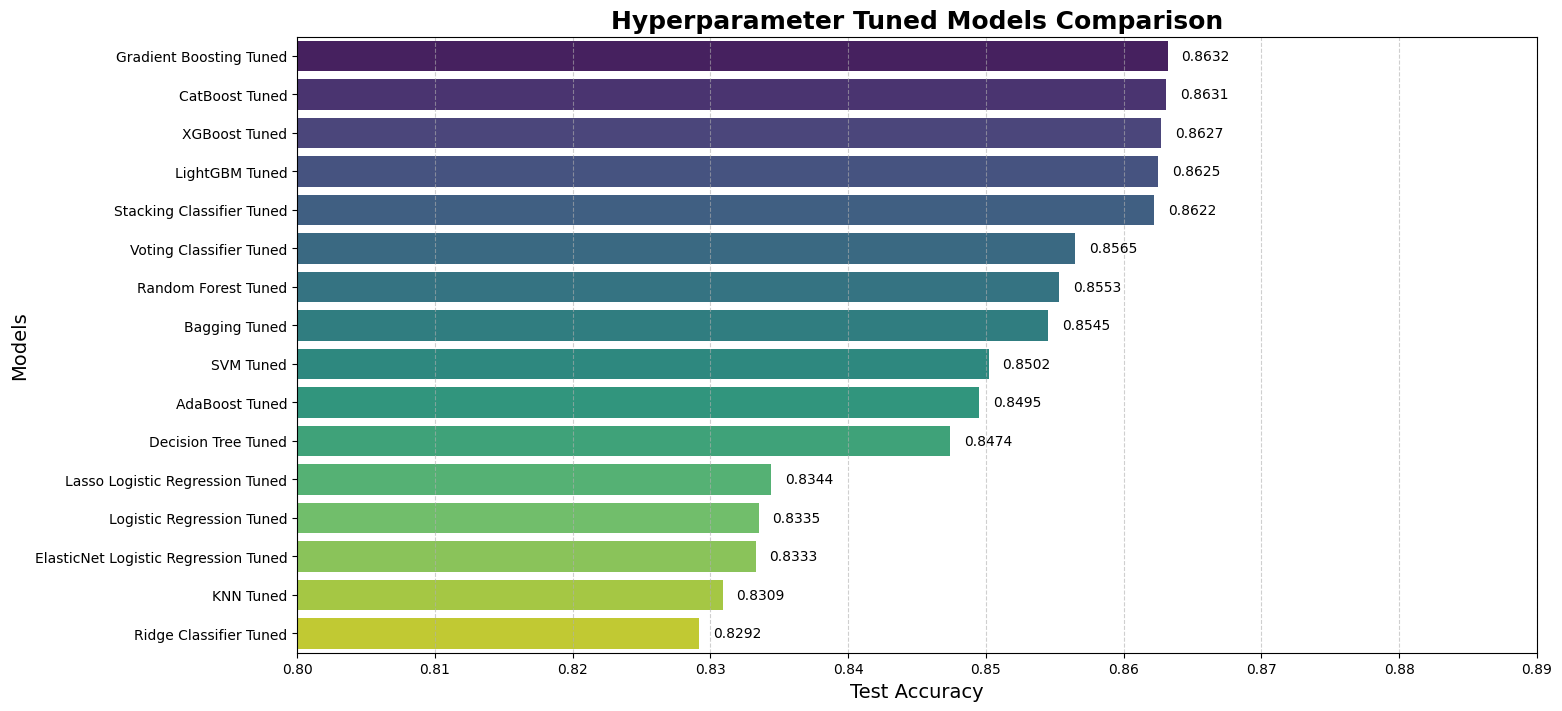

In [80]:
# =========================================================
# TUNING MODEL ACCURACY COMPARISON
# =========================================================

# =========================================================
# SET FIGURE SIZE
# =========================================================

plt.figure(figsize=(16, 8))

# =========================================================
# CREATE BARPLOT
# =========================================================

sns.barplot(

    data=tuned_model_results_df,

    x='Test Accuracy',
    y='Model',

    palette='viridis'
)

# =========================================================
# ADD TITLE
# =========================================================

plt.title(

    'Hyperparameter Tuned Models Comparison',
    
    fontsize=18,
    
    fontweight='bold'
)

# =========================================================
# X AND Y LABELS
# =========================================================

plt.xlabel(

    'Test Accuracy',
    
    fontsize=14
)

plt.ylabel(

    'Models',
    
    fontsize=14
)

# =========================================================
# X-AXIS LIMIT
# =========================================================

plt.xlim(0.80, 0.89)

# =========================================================
# SHOW GRID
# =========================================================

plt.grid(

    axis='x',
    
    linestyle='--',
    
    alpha=0.6
)

# =========================================================
# SHOW VALUES ON BARS
# =========================================================

for index, value in enumerate(
    
    tuned_model_results_df['Test Accuracy']
):
    
    plt.text(
        
        value + 0.001,
        
        index,
        
        f'{value:.4f}',
        
        va='center',
        
        fontsize=10
    )

# =========================================================
# SHOW PLOT
# =========================================================

plt.show()

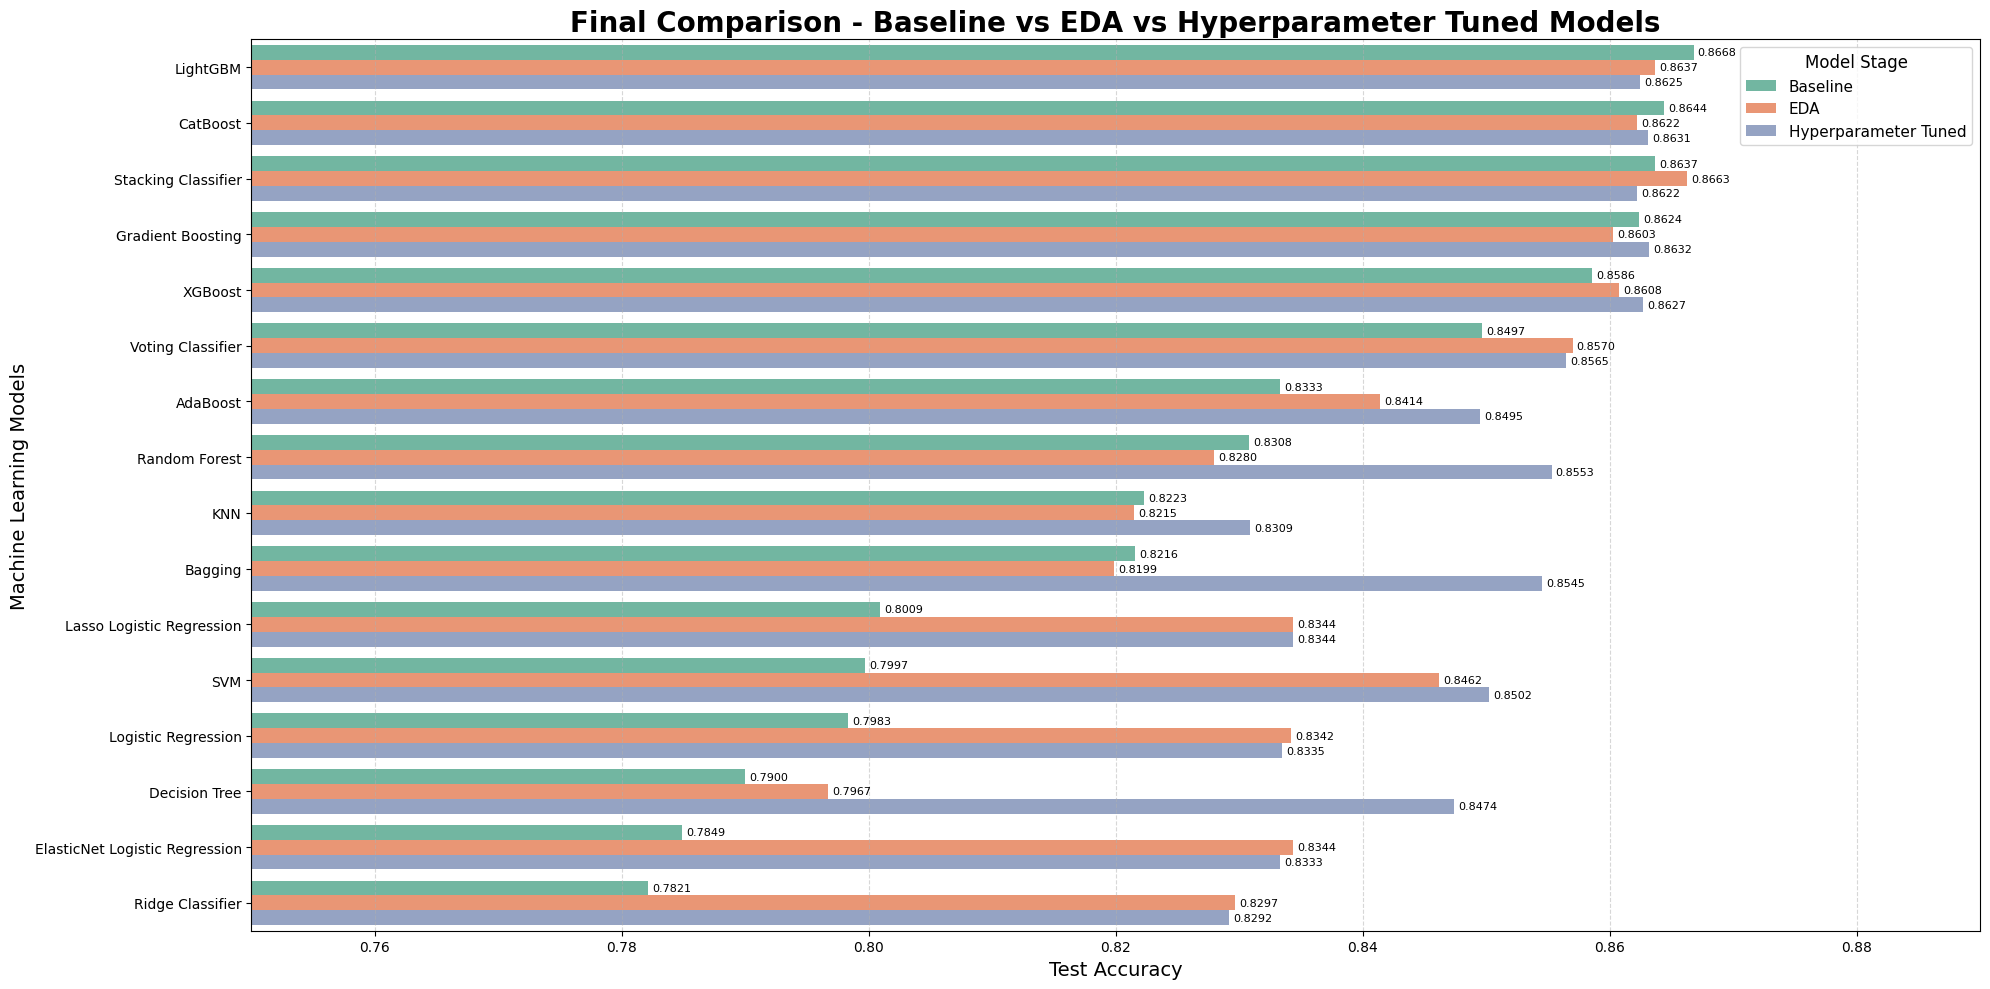

In [81]:
# =========================================================
# CREATE COMPARISON DATAFRAMES
# =========================================================

baseline_compare_df = baseline_model_results_df[[

    'Model',
    'Test Accuracy'
]].copy()

baseline_compare_df['Stage'] = 'Baseline'

# =========================================================

eda_compare_df = eda_model_results_df[[

    'Model',
    'Test Accuracy'
]].copy()

eda_compare_df['Stage'] = 'EDA'

# =========================================================

tuned_compare_df = tuned_model_results_df[[

    'Model',
    'Test Accuracy'
]].copy()

tuned_compare_df['Stage'] = 'Hyperparameter Tuned'

# =========================================================
# STANDARDIZE MODEL NAMES
# =========================================================

baseline_compare_df['Model'] = baseline_compare_df['Model'].str.replace(
    
    ' Baseline',
    '',
    regex=False
)

eda_compare_df['Model'] = eda_compare_df['Model'].str.replace(
    
    ' EDA',
    '',
    regex=False
)

tuned_compare_df['Model'] = tuned_compare_df['Model'].str.replace(
    
    ' Tuned',
    '',
    regex=False
)

# =========================================================
# COMBINE DATAFRAMES
# =========================================================

final_comparison_df = pd.concat([

    baseline_compare_df,
    eda_compare_df,
    tuned_compare_df

], ignore_index=True)

# =========================================================
# CREATE FIGURE
# =========================================================

plt.figure(figsize=(20, 10))

# =========================================================
# CREATE BARPLOT
# =========================================================

ax = sns.barplot(

    data=final_comparison_df,

    x='Test Accuracy',
    y='Model',

    hue='Stage',

    palette='Set2'
)

# =========================================================
# ADD TITLE
# =========================================================

plt.title(

    'Final Comparison - Baseline vs EDA vs Hyperparameter Tuned Models',
    
    fontsize=20,
    
    fontweight='bold'
)

# =========================================================
# X AND Y LABELS
# =========================================================

plt.xlabel(

    'Test Accuracy',
    
    fontsize=14
)

plt.ylabel(

    'Machine Learning Models',
    
    fontsize=14
)

# =========================================================
# X-AXIS LIMIT
# =========================================================

plt.xlim(0.75, 0.89)

# =========================================================
# ADD GRID
# =========================================================

plt.grid(

    axis='x',
    
    linestyle='--',
    
    alpha=0.5
)

# =========================================================
# ADD LEGEND
# =========================================================

plt.legend(

    title='Model Stage',
    
    fontsize=11,
    
    title_fontsize=12
)

# =========================================================
# ADD ACCURACY LABELS
# =========================================================

for container in ax.containers:
    
    ax.bar_label(
        
        container,
        
        fmt='%.4f',
        
        padding=3,
        
        fontsize=8
    )

# =========================================================
# LAYOUT
# =========================================================

plt.tight_layout()

# =========================================================
# SHOW PLOT
# =========================================================

plt.show()

In [82]:
# =========================================================
# CREATE FINAL LIGHTGBM MODEL
# =========================================================

final_lightgbm_model = LGBMClassifier(random_state=10)

# =========================================================
# TRAIN MODEL
# =========================================================

final_lightgbm_model.fit(x_train, y_train)

print("Final LightGBM model trained successfully.")

Final LightGBM model trained successfully.


In [83]:
# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(final_lightgbm_model, 'lightgbm_model.pkl')

print("LightGBM model saved successfully.")

LightGBM model saved successfully.


In [84]:
# =========================================================
# CREATE FEATURE IMPORTANCE DATAFRAME
# =========================================================

feature_importance_df = pd.DataFrame({'Feature': x.columns, 'Importance': final_lightgbm_model.feature_importances_})

# =========================================================
# SORT VALUES
# =========================================================

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# =========================================================
# SAVE CSV
# =========================================================

feature_importance_df.to_csv('feature_importance.csv', index=False)

print("Feature Importance CSV saved successfully.")

Feature Importance CSV saved successfully.


In [85]:
# =========================================================
# CREATE ENCODERS DICTIONARY
# =========================================================

label_encoders = {}

# =========================================================
# ENCODE CATEGORICAL COLUMNS
# =========================================================

for column in df.select_dtypes(include='object').columns:

    le = LabelEncoder()

    df_encoded[column] = le.fit_transform(df[column])

    label_encoders[column] = le

# =========================================================
# SAVE ENCODERS
# =========================================================

joblib.dump(label_encoders, 'label_encoders.pkl')

print("Label Encoders Saved Successfully.")

Label Encoders Saved Successfully.


In [86]:
df.to_csv("dataset_cleaned.csv", index=False)